In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

df = pd.read_csv('../dataset/predict_prices_dataset.csv')
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi


# Polynomial Regression — Degree Sweep on Numeric Features

In [14]:
x = df.select_dtypes(include='number').drop(columns=['price'])
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

poly = PolynomialFeatures(degree=5, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred_train = model.predict(x_train_poly)
y_pred_test = model.predict(x_test_poly)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test  MAE:", mean_absolute_error(y_test,  y_pred_test))

print(x_train_poly.shape)

Train RMSE: 3771.92
Test RMSE: 6163.01
Train R²: 0.8344299065873739
Test  R²: 0.5715099017209073
Train MAE: 2584.3871702119086
Test  MAE: 2703.5715130013223
(57948, 251)


Starting from a plain linear regression baseline (R² = 0.71) on numeric-only features, I gradually increased the polynomial degree to observe the full bias–variance curve. Degrees 2 through 4 produced steady, healthy gains with train and test scores staying almost identical — a sign of good generalization. Degree 5 collapsed spectacularly on the test set while train barely moved, providing a textbook demonstration of overfitting caused by high-degree polynomial oscillations and an explosion in feature count. The sweet spot for this dataset sits at **degree 3**, where performance is nearly optimal and the model stays compact and stable.

## Comparison Table

| Degree | Train R² | Test R² | Train RMSE | Test RMSE | Train MAE | Test MAE | # Features | Verdict |
|:------:|:--------:|:-------:|:----------:|:---------:|:---------:|:--------:|:----------:|:-------|
| 1 (linear) | — | 0.71 | — | 5067.32 | — | 3327.38 | ~5 | Underfitting — misses curvature |
| 2 | 0.789 | 0.784 | 4253 | 4375 | 2797 | 2806 | ~20 | Solid improvement, no overfit |
| 3 | 0.818 | 0.814 | 3957 | 4056 | 2637 | 2640 | ~55 | **Sweet spot** — best value/complexity |
| 4 | 0.828 | 0.822 | 3843 | 3969 | 2599 | 2610 | 125 | Marginal gain, still stable |
| 5 | 0.834 | **0.572** | 3772 | **6163** | 2584 | 2704 | 251 | Severe overfitting — train–test gap = 0.26 |

# Polynomial Regression — Adding Categorical Features

In [ ]:
df_encoded = pd.get_dummies(df, columns=['transmission', 'fuelType', 'Make'], drop_first=True)
train_df, test_df = train_test_split(df_encoded, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
# Fallback for models that appear only in test (unseen in train)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

# Separate features from target, drop the raw 'model' text column
x_train = train_df.drop(columns=['price', 'model'])
x_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred_train = model.predict(x_train_poly)
y_pred_test = model.predict(x_test_poly)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test  MAE:", mean_absolute_error(y_test,  y_pred_test))

print(x_train_poly.shape)

Train RMSE: 2472.67
Test RMSE: 2704.12
Train R²: 0.9288479758736248
Test  R²: 0.9175092728547223
Train MAE: 1642.395941306974
Test  MAE: 1653.9167433716666
(57948, 209)


After maxing out numeric-only polynomial regression at Test R² ≈ 0.82, I moved to phase 2: bringing in the categorical columns (`transmission`, `fuelType`, `Make` via one-hot encoding, `model` via target encoding). The jump was dramatic — degree 2 alone pushed Test R² from 0.78 to **0.918** and cut Test MAE from ~2800 to ~1650, confirming that most of the price signal lives in the categorical features, not in the numeric ones. Degree 3, however, collapsed spectacularly: with 1539 generated features, the model overfitted so badly that Test R² fell to 0.28 and Test RMSE tripled, while Train R² kept climbing. The lesson is clear — **feature engineering (adding categoricals) beat model complexity (higher degree) by a wide margin**, and the sweet spot is degree 2 with all features.

## Comparison Table (Polynomial + Categorical Features)

| Degree | Train R² | Test R² | Train RMSE | Test RMSE | Train MAE | Test MAE | # Features | Verdict |
|:------:|:--------:|:-------:|:----------:|:---------:|:---------:|:--------:|:----------:|:-------|
| 2 | 0.929 | **0.918** | 2473 | **2704** | 1642 | **1654** | 209 | **Sweet spot** — huge gain over numeric-only, no overfitting |
| 3 | 0.947 | 0.279 | 2137 | 7997 | 1429 | 1549 | 1539 | Catastrophic overfitting — train–test gap = 0.67 |

# Feature Engineering — Log Transforms, a Ratio Feature, and Ridge

Degree 2 with all features plateaued at Test R² ≈ 0.918, and I already saw that plain degree 3 blows up (Test R² 0.28). So instead of just cranking the degree, I tried three other things to squeeze out more: log-transform skewed columns, add a ratio feature the polynomial can't build on its own, and regularize with Ridge so degree 3 becomes usable again.

## Log Transforms

First idea: find a column with a curved / skewed relationship to price and log it, so the model gets a straighter signal to fit. `mileage` was the obvious candidate — the histogram below is heavily right-skewed (most cars under ~60k km, a long thin tail out past 250k). I also looked at scatter plots of mileage vs price (clear exponential-decay shape) and mileage vs log(price) (looked more linear), which is what made log worth trying at all.

<Axes: xlabel='mileage', ylabel='Count'>

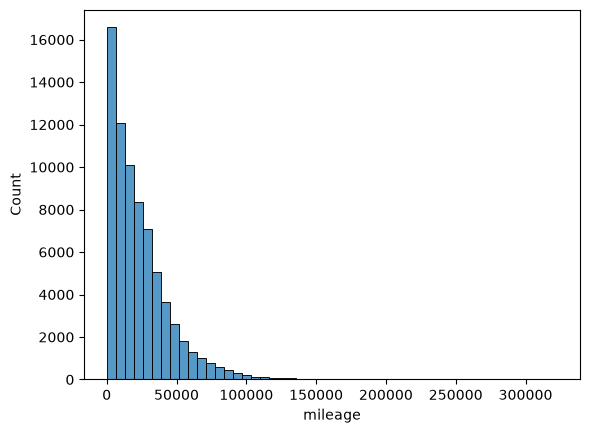

In [21]:
import seaborn as sns
sns.histplot(df['mileage'], bins=50)

<Axes: xlabel='mileage', ylabel='Count'>

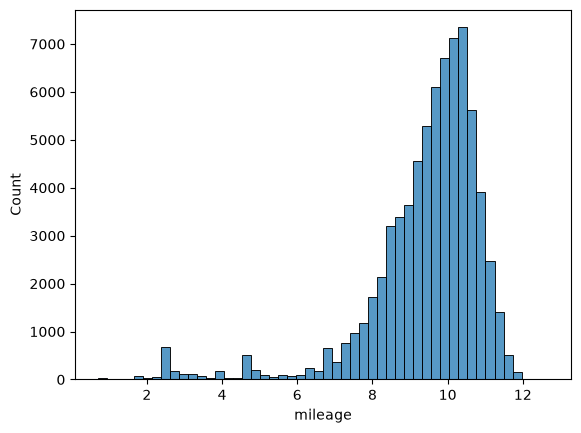

In [23]:
sns.histplot(np.log(df['mileage'] + 1), bins=50)

Logging mileage over-corrected. Instead of a clean bell it flipped to a left-skew with an odd little bump around 2–5 (near-new cars, basically a second distribution mixed in), so it didn't make the feature any nicer to model. I also tried `log(price)` on the target: I retrained the whole degree-2 model on `np.log(y)` and mapped predictions back with `np.exp` before scoring. The numbers barely moved, and if anything got slightly worse:

| Target | Test R² | Test RMSE | Test MAE |
|:-------|:-------:|:---------:|:--------:|
| price (raw)  | 0.918 | 2704 | 1654 |
| log(price)   | 0.913 | 2780 | 1624 |

Dropped both log transforms, they weren't earning their keep here.

## A Ratio Feature + Outlier Removal

Two changes that did help, both applied before the split:

- `km_per_year = mileage / (2024 - year + 1)` — a genuinely new signal. The polynomial only multiplies and raises to powers, it can't divide, so it could never build "usage intensity" out of `mileage` and `year` on its own. A 3-year-old car with 180k km is a very different animal from a 10-year-old with 60k km, and this captures that.
- Outlier removal: dropped junk rows (`price < 500`, `mpg > 400`, `year < 2001`). Only ~50 rows, but they were the extreme points the polynomial was latching onto.

The cell below is degree 3 with plain LinearRegression — and notice it does **not** collapse anymore (Test R² 0.936, not the 0.28 from before). Same degree, same ~1770 columns. Trimming the tail of the distribution removed the extreme feature values that were making the degree-3 terms swing wildly on the test set. Outlier removal and Ridge fix the same failure mode — huge coefficients reacting to rare, extreme points — from two different angles.

In [35]:
df['km_per_year'] = df['mileage'] / (2024 - df['year'] + 1)

df_encoded = pd.get_dummies(df, columns=['transmission', 'fuelType', 'Make'], drop_first=True)
df_clean = df_encoded[df_encoded['price'] >= 500]
df_clean = df_clean[df_clean['mpg'] <= 400]
df_clean = df_clean[df_clean['year'] >= 2001]
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

x_train = train_df.drop(columns=['price', 'model'])
x_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

poly = PolynomialFeatures(degree=3, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred_train = model.predict(x_train_poly)
y_pred_test = model.predict(x_test_poly)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test  MAE:", mean_absolute_error(y_test,  y_pred_test))

print(x_train_poly.shape)

Train RMSE: 2148.60
Test RMSE: 2374.98
Train R²: 0.9463010066370648
Test  R²: 0.9363091400252362
Train MAE: 1409.7000239364563
Test  MAE: 1449.9066632357064
(57896, 1770)


## Ridge on Degree 3 + Alpha Tuning

Last piece: Ridge. Ridge is just linear regression with a penalty on large coefficients (`alpha * sum(coef^2)`) — the bigger the alpha, the harder it fights oversized coefficients, which is exactly what tames the leftover rare-interaction terms at degree 3. I swept alpha; the test score kept improving up to a point, then over-regularized:

| alpha | Train R² | Test R² | Test RMSE | Test MAE | Note |
|:-----:|:--------:|:-------:|:---------:|:--------:|:-----|
| 1      | 0.9464 | 0.9361 | 2380 | 1449 | too weak |
| 10     | 0.9464 | 0.9382 | 2339 | 1445 | better |
| 100    | 0.9461 | 0.9409 | 2288 | 1445 | strong, gap shrinking |
| 1000   | 0.9448 | **0.9427** | **2253** | 1458 | best test R² |
| 10000  | 0.9408 | 0.9405 | 2295 | 1512 | over-regularized |

The optimum sits around alpha 1000. Push past that (10000) and train R² drops hard while MAE jumps to 1512 — the model gets too rigid and starts throwing away useful coefficients, not just noisy ones. The cell below runs the alpha=1000 version.

In [34]:
poly = PolynomialFeatures(degree=3, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

model = Ridge(alpha=1000.0)
model.fit(x_train_poly, y_train)
y_pred_train = model.predict(x_train_poly)
y_pred_test = model.predict(x_test_poly)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test  MAE:", mean_absolute_error(y_test,  y_pred_test))

print(x_train_poly.shape)

Train RMSE: 2178.14
Test RMSE: 2252.97
Train R²: 0.9448146018921582
Test  R²: 0.9426852714333358
Train MAE: 1429.288565552139
Test  MAE: 1457.5826459150674
(57896, 1770)


## Full Progression

The whole arc of the experiment, best test score at each step:

| Step | Test R² | Test MAE |
|:-----|:-------:|:--------:|
| Linear, numeric only | 0.71 | 3327 |
| Poly degree 3, numeric only | 0.81 | 2640 |
| Poly degree 2, + categoricals | 0.918 | 1654 |
| + km_per_year | 0.920 | 1628 |
| + outlier removal | 0.930 | 1632 |
| + Ridge degree 3 (alpha=1000) | 0.943 | 1458 |

By far the biggest single jump was adding the categorical features — feature engineering beat every bit of degree and model tuning. After that it was diminishing returns: the ratio feature, outlier trimming, and Ridge each added a little, taking it from 0.918 to ~0.943. For a used-car price model that's a solid place to stop. Getting past ~0.95 would mean switching to a non-linear model like gradient boosting, which is a different tool than polynomial regression.